## Data Extraction

In [52]:
import pandas as pd
df = pd.read_csv('/kaggle/input/flickr30k/captions.txt', header=0)
df.sample(5)

,image,caption
5229,132966111.jpg,A charity walk happening with balloons .
82175,3693255006.jpg,5 Asian males in swimming trunks sitting and ...
108145,4640634694.jpg,A straight-haired white woman wearing sunglas...
111183,4689844217.jpg,Three children smiling for the camera .
19148,217330024.jpg,A man is about to regret letting his friend t...


In [53]:
df.shape

(158915, 2)

## Image Data Processing

In [57]:
import matplotlib.pyplot as plt
from PIL import Image
import os

BASE_PATH = '/kaggle/input/flickr30k/Images'
SUBDIR = os.path.join(BASE_PATH, 'flickr30k_images')

def display_image(row):
    filename = row['image']
    caption = row['caption']
    
    # Resolve actual image path
    path1 = os.path.join(BASE_PATH, filename)
    path2 = os.path.join(SUBDIR, filename)
    img_path = path1 if os.path.exists(path1) else path2
    
    # Load and display
    img = Image.open(img_path).convert('RGB')
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(caption, wrap=True, fontsize=12)
    plt.axis('off')
    plt.show()

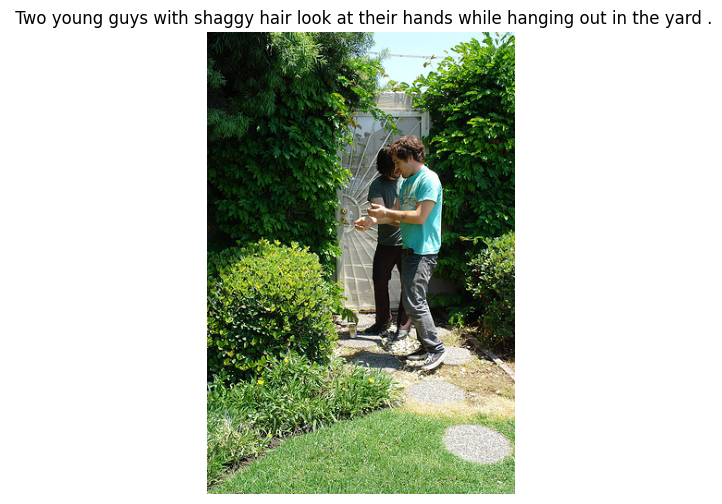

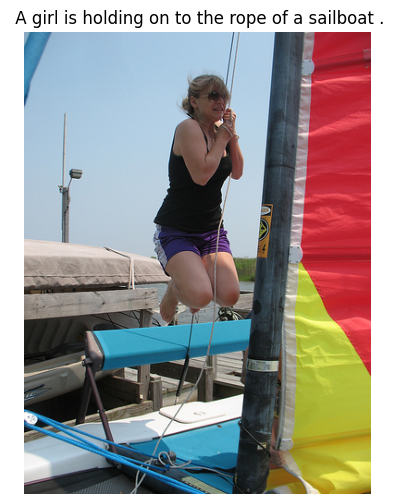

In [58]:
display_image(df.iloc[0])      # single example
display_image(df.sample(1).iloc[0])  # random example

In [6]:
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image
import os


class ImageDataset(Dataset):
    def __init__(self, image_names, transform):
        self.image_names = image_names
        self.transform = transform

    def _resolve_path(self, name):
        p1 = os.path.join(BASE_PATH, name)
        p2 = os.path.join(SUBDIR, name)
        return p1 if os.path.exists(p1) else p2

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        name = self.image_names.iloc[idx]
        img = Image.open(self._resolve_path(name)).convert('RGB')
        return self.transform(img), name

In [7]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
import pickle
from tqdm import tqdm


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Loeading resnet model
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Remove final FC layer
model = nn.Sequential(*list(model.children())[:-1]) 
model = model.to(device)
model.eval()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [8]:
# Standard ImageNet preprocessing for resnet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Use UNIQUE images only
unique_images = df['image'].drop_duplicates().reset_index(drop=True)
dataset = ImageDataset(unique_images, transform)
# Data loader
loader = DataLoader(dataset, batch_size=128, num_workers=4, shuffle=False)

In [9]:
# Feature extraction 
features_dict = {}
with torch.no_grad():
    for imgs, names in tqdm(loader, desc="Extracting Features"):
        feats = model(imgs.to(device))  # shape: [B, 2048, 1, 1]
        feats = feats.view(feats.size(0), -1).cpu().numpy()  # [B, 2048]
        for i, name in enumerate(names):
            features_dict[name] = feats[i]

# Save
OUTPUT_FILE = 'flickr30k_features.pkl'
with open(OUTPUT_FILE, 'wb') as f:
    pickle.dump(features_dict, f)

print(f"Done! {len(features_dict)} unique images saved to {OUTPUT_FILE}")

Extracting Features: 100%|██████████| 249/249 [02:14<00:00,  1.85it/s]


Done! 31783 unique images saved to flickr30k_features.pkl


In [ ]:
# # If loading already saved pkl file
# with open('/kaggle/working/flickr30k_features.pkl', 'rb') as f:
#     features_dict = pickle.load(f)

## Text processing

In [11]:
import re
from collections import Counter

# Clean captions
def clean_caption(text):
    if not isinstance(text, str):
        return "" 

    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join(text.split())
    return text

df['caption'] = df['caption'].apply(clean_caption)

#### Build Vocabulary

In [12]:
# Aggregation operations on description
word_lens = df['caption'].str.split().str.len()
stats = {
    'avg': word_lens.mean(),
    'min': word_lens.min(),
    'max': word_lens.max(),
    '90th_percentile': word_lens.quantile(0.90)
}
stats

{'avg': np.float64(12.250605669697638),
 'min': 0,
 'max': 78,
 '90th_percentile': np.float64(19.0)}

In [18]:
tokens = []
# tokenize all captions
for c in df['caption']:
    tokens.extend(c.split())

# Count & filter rare words
min_freq = 5
counter = Counter(tokens)
vocab_words = [w for w,c in counter.items() if c >= min_freq]

# Include special tokens
PAD, START, END, UNK = '<pad>', '<start>', '<end>', '<unk>'
vocab = [PAD, START, END, UNK] + vocab_words

word2idx = {word: idx for idx,word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}
VOCAB_SIZE = len(vocab)
print(VOCAB_SIZE)

7689


In [26]:
# Tokenize a caption and converts each word into its corresponding integer ID
def caption_to_indices(caption):
    tokens = caption.split()
    indices = [word2idx.get(w, word2idx[UNK]) for w in tokens]
    return [word2idx[START]] + indices + [word2idx[END]]

df['caption_ids'] = df['caption'].apply(caption_to_indices)

## Caption Dataset

In [27]:
# max length of sequence to retain
MAX_LEN = 25

In [28]:
from torch.nn.utils.rnn import pad_sequence

class CaptionDataset(Dataset):
    def __init__(self, df, features_dict, word2idx, max_len=MAX_LEN):
        self.df = df.reset_index(drop=True)
        self.features = features_dict
        self.word2idx = word2idx
        self.max_len = max_len
        self.pad_id = word2idx['<pad>']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['image']
        caption_ids = row['caption_ids']  # already includes <start> and <end>

        # Truncate caption
        if len(caption_ids) > self.max_len:
            caption_ids = caption_ids[:self.max_len]
        # pad caption
        else:
            caption_ids = caption_ids + [self.pad_id] * (self.max_len - len(caption_ids))

        feature = self.features[img_name] # [2048]

        return (
            torch.tensor(feature, dtype=torch.float32),      # [2048]
            torch.tensor(caption_ids, dtype=torch.long)      # [max_len]
        )

In [30]:
# Create dataset instance
dataset = CaptionDataset(df, features_dict, word2idx, max_len=MAX_LEN)

# Test one sample
feat, cap_ids = dataset[100]
print("Feature shape:", feat.shape)          # torch.Size([2048])
print("Caption IDs shape:", cap_ids.shape)   # torch.Size([20])
print("Caption tokens:", [idx2word[i.item()] for i in cap_ids])

Feature shape: torch.Size([2048])
Caption IDs shape: torch.Size([25])
Caption tokens: ['<start>', 'a', 'person', 'in', 'gray', 'stands', 'alone', 'on', 'a', 'structure', 'outdoors', 'in', 'the', 'dark', '<end>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


## Seq2Seq (Encoder-Decoder) Model

In [31]:
FEATURE_DIM = 2048
HIDDEN_SIZE = 512
EMBED_DIM = 256
NUM_LAYERS = 1
DROPOUT = 0.3

class Encoder(nn.Module):
    def __init__(self, feature_dim=FEATURE_DIM, hidden_size=HIDDEN_SIZE, dropout=DROPOUT):
        super().__init__()
        self.fc = nn.Linear(feature_dim, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, img_features): # [B, 2048]
        return self.dropout(self.relu(self.fc(img_features))) # [B, hidden_size]


class Decoder(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout_emb = nn.Dropout(dropout)
        self.lstm = nn.LSTM(embed_dim, hidden_size, batch_first=True)
        self.dropout_out = nn.Dropout(dropout)
        self.fc_out = nn.Linear(hidden_size, vocab_size) # [512, vocab_size]

    def forward(self, caption_ids, encoder_hidden):
        # caption_ids -> [B, seq_len]
        embedded = self.dropout_emb(self.embedding(caption_ids)) # [B, seq_len, embed_dim]
        # Use encoder output as initial hidden state
        h0 = encoder_hidden.unsqueeze(0).contiguous() # [1, B, hidden_size]
        c0 = torch.zeros_like(h0) # [1, B, hidden_size]
        outputs, _ = self.lstm(embedded, (h0, c0))  # [B, L, hidden_size]
        outputs = self.dropout_out(outputs)
        logits = self.fc_out(outputs)  # [B, L, vocab_size]
        return logits

## Training

In [32]:
import torch.optim as optim

# Hyperparameters
BATCH_SIZE = 256
EPOCHS = 20
LR = 1e-4
PAD_IDX = word2idx['<pad>']

encoder = Encoder(feature_dim=FEATURE_DIM, hidden_size=HIDDEN_SIZE).to(device)
decoder = Decoder(vocab_size=len(word2idx), embed_dim=EMBED_DIM, hidden_size=HIDDEN_SIZE).to(device)
optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

In [33]:
# Get UNIQUE image names
unique_images = df['image'].drop_duplicates().reset_index(drop=True)

# Split by unique image count
n = len(unique_images) 
n_train = int(0.8 * n)
n_val = int(0.1 * n)

train_images = set(unique_images[:n_train])
val_images = set(unique_images[n_train:n_train + n_val])
test_images = set(unique_images[n_train + n_val:])

# Create DataFrames
train_df = df[df['image'].isin(train_images)].reset_index(drop=True)
val_df = df[df['image'].isin(val_images)].reset_index(drop=True)
test_df = df[df['image'].isin(test_images)].reset_index(drop=True)

train_dataset = CaptionDataset(train_df, features_dict, word2idx, max_len=MAX_LEN)
val_dataset = CaptionDataset(val_df, features_dict, word2idx, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [34]:
from tqdm import tqdm

for epoch in range(EPOCHS):
    # Training
    encoder.train()
    decoder.train()
    total_train_loss = 0
    for img_feats, cap_ids in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        img_feats = img_feats.to(device)
        cap_ids = cap_ids.to(device)
        decoder_input = cap_ids[:, :-1]      # [B, L-1]
        targets = cap_ids[:, 1:]             # [B, L-1]

        enc_out = encoder(img_feats)         # [B, 512]
        logits = decoder(decoder_input, enc_out)  # [B, L-1, vocab_size]

        # Flatten for loss
        loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # Validation
    encoder.eval()
    decoder.eval()
    total_val_loss = 0
    with torch.no_grad():
        for img_feats, cap_ids in val_loader:
            img_feats = img_feats.to(device)
            cap_ids = cap_ids.to(device)
            decoder_input = cap_ids[:, :-1]
            targets = cap_ids[:, 1:]

            enc_out = encoder(img_feats)
            logits = decoder(decoder_input, enc_out)
            loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch 1/20: 100%|██████████| 497/497 [00:41<00:00, 12.03it/s]


Epoch 1/20 | Train Loss: 5.3154 | Val Loss: 4.6985


Epoch 2/20: 100%|██████████| 497/497 [00:40<00:00, 12.40it/s]


Epoch 2/20 | Train Loss: 4.3448 | Val Loss: 4.3606


Epoch 3/20: 100%|██████████| 497/497 [00:40<00:00, 12.34it/s]


...

Epoch 18/20 | Train Loss: 3.0823 | Val Loss: 3.3136


Epoch 19/20: 100%|██████████| 497/497 [00:40<00:00, 12.33it/s]


Epoch 19/20 | Train Loss: 3.0564 | Val Loss: 3.2989


Epoch 20/20: 100%|██████████| 497/497 [00:40<00:00, 12.33it/s]


Epoch 20/20 | Train Loss: 3.0330 | Val Loss: 3.2817


In [35]:
# Saving model
torch.save({
    'encoder_state_dict': encoder.state_dict(),
    'decoder_state_dict': decoder.state_dict(),
    'hyperparams': {
        'hidden_size': HIDDEN_SIZE,
        'embed_dim': EMBED_DIM,
        'vocab_size': VOCAB_SIZE,
        'feature_dim': FEATURE_DIM,
    }
}, 'caption_model.pth')

## Inference

In [36]:
test_dataset = CaptionDataset(test_df, features_dict, word2idx, max_len=MAX_LEN)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [37]:
def greedy_decode(encoder, decoder, img_feature, word2idx, idx2word, max_len=20):
    """
    Generate caption for a single image feature using greedy search.
    img_feature: np.array or torch.Tensor of shape [2048]
    """
    device = next(encoder.parameters()).device
    if isinstance(img_feature, np.ndarray):
        img_feature = torch.tensor(img_feature, dtype=torch.float32).to(device)
    else:
        img_feature = img_feature.to(device)

    # Encode image
    with torch.no_grad():
        enc_out = encoder(img_feature.unsqueeze(0))  # [1, 512]

    # Start with <start>
    current_word = torch.tensor([[word2idx['<start>']]], device=device)  # [1, 1]
    caption = []

    for _ in range(max_len - 1):  # leave room for <end>
        with torch.no_grad():
            logits = decoder(current_word, enc_out)  # [1, 1, vocab_size]
            pred_id = logits.argmax(dim=-1).item()   # scalar

        word = idx2word[pred_id]
        if word == '<end>':
            break
        caption.append(word)
        current_word = torch.tensor([[pred_id]], device=device)

    return ' '.join(caption)

In [38]:
checkpoint = torch.load('/kaggle/working/caption_model.pth', map_location=device)
hp = checkpoint['hyperparams']

encoder = Encoder(hp['feature_dim'], hp['hidden_size']).to(device)
decoder = Decoder(hp['vocab_size'], hp['embed_dim'], hp['hidden_size']).to(device)

encoder.load_state_dict(checkpoint['encoder_state_dict'])
decoder.load_state_dict(checkpoint['decoder_state_dict'])

<All keys matched successfully>

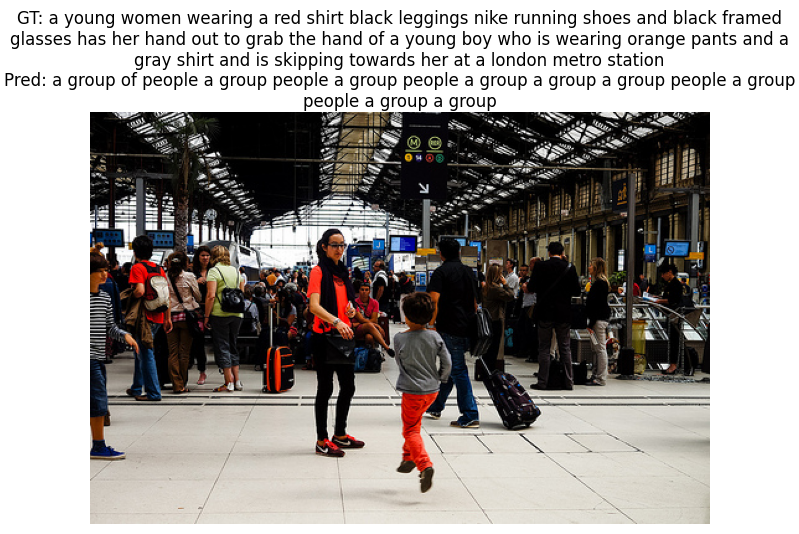

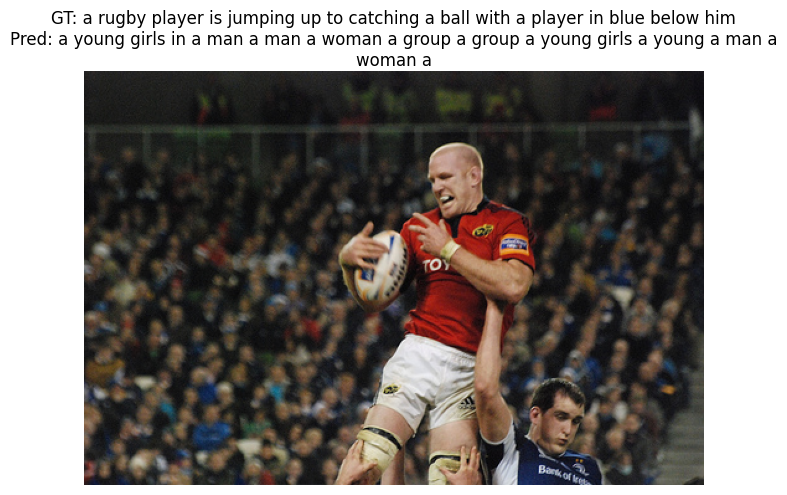

In [46]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Pick 5 unique test images
test_images = test_df['image'].drop_duplicates().sample(2).tolist()

for img_name in test_images:
    # Resolve path
    path = os.path.join('/kaggle/input/flickr30k/Images', img_name)
    if not os.path.exists(path):
        path = os.path.join('/kaggle/input/flickr30k/Images/flickr30k_images', img_name)
    
    # Load image
    img = Image.open(path).convert('RGB')
    
    # Get ground truth caption
    gt = test_df[test_df['image'] == img_name]['caption'].iloc[0]
    
    # Generate caption
    pred = greedy_decode(encoder, decoder, features_dict[img_name], word2idx, idx2word, max_len=MAX_LEN)
    
    # Display
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f"GT: {gt}\nPred: {pred}", wrap=True)
    plt.axis('off')
    plt.show()

## Performance Metrices

In [47]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# Evaluate
all_preds = []
all_refs = []

with torch.no_grad():
    for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
        img_name = row['image']
        gt_caption = row['caption'].split()
        
        pred_caption = greedy_decode(
            encoder, decoder,
            features_dict[img_name],
            word2idx, idx2word,
            max_len=MAX_LEN
        ).split()
        
        all_preds.append(pred_caption)
        all_refs.append([gt_caption])  # BLEU expects list of refs per pred

# BLEU-4
bleu = corpus_bleu(all_refs, all_preds, smoothing_function=SmoothingFunction().method1)

# Token F1 (micro)
from sklearn.metrics import precision_recall_fscore_support
all_pred_toks = [t for p in all_preds for t in p]
all_ref_toks = [t for r_list in all_refs for r in r_list for t in r]

y_true = [word2idx.get(t, word2idx['<unk>']) for t in all_ref_toks]
y_pred = [word2idx.get(t, word2idx['<unk>']) for t in all_pred_toks]

# Pad to same length
n = max(len(y_true), len(y_pred))
y_true += [word2idx['<pad>']] * (n - len(y_true))
y_pred += [word2idx['<pad>']] * (n - len(y_pred))

_, _, f1, _ = precision_recall_fscore_support(
    y_true, y_pred,
    average='micro',
    labels=[i for i in range(len(word2idx)) if i != word2idx['<pad>']]
)

print(f"Test BLEU-4: {bleu:.4f}")
print(f"Test Token F1: {f1:.4f}")

100%|██████████| 15895/15895 [03:32<00:00, 74.82it/s]


Test BLEU-4: 0.0095
Test Token F1: 0.0451


In [49]:
perplexity = torch.exp(torch.tensor(avg_val_loss)).item()
print(f"Perplexity: {perplexity:.2f}") 

Perplexity: 26.62
